# visualization.network-bacteria-virus


In this notebook, we will create networks that allow us to study the interactions between virus, bacteria and hosts. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import igraph  as ig
import networkx as nx
import random
habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'

## Virus/bacteria - host weighted matrix

In [3]:
metadata = pd.read_csv("output/metadata.site-library.csv", sep=";")


In [4]:
bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_host = bacteria_hits.value_counts(
    ['host_taxon', 'taxid', 'scientific_name', 'habitat']
).reset_index()
bacteria_host['type'] = 'bacteria'
bacteria_host = bacteria_host[['host_taxon', 'scientific_name', 'habitat', 'type', 'count']].copy().rename(columns={'scientific_name': 'scientific_name'}).copy()
bacteria_host

,host_taxon,scientific_name,habitat,type,count
0,Cucumis melo,Bradyrhizobium elkanii,Crop,bacteria,3
1,Convolvulus arvensis,Rhodococcoides fascians,Edge,bacteria,3
2,Daucus sp,Rhodococcoides fascians,Edge,bacteria,2
3,Cynodon dactylon,Frigoribacterium sp. Leaf164,Edge,bacteria,2
4,Quercus coccifera,Bradyrhizobium sp. DFCI-1,Oak,bacteria,2
...,...,...,...,...,...
411,Convolvulus arvensis,Chryseobacterium sp. Leaf201,Wasteland,bacteria,1
412,Convolvulus arvensis,Chryseobacterium sp. Leaf201,Edge,bacteria,1
413,Convolvulus arvensis,Xaviernesmea rhizosphaerae,Crop,bacteria,1
414,Convolvulus arvensis,Aureimonas sp. AU12,Edge,bacteria,1


In [5]:
virus_edges = pd.read_csv("input/network.mcleish24.links.csv", sep="\t").value_counts(['host', 'virus', 'habitat']).reset_index()
virus_nodes = pd.read_csv("input/network.mcleish24.nodes.csv", sep="\t")
virus_edges = pd.merge(virus_edges, virus_nodes[['id', 'taxon']], how='inner', left_on='host', right_on='id')
virus_edges = pd.merge(virus_edges, virus_nodes[['id', 'taxon']], how='inner', left_on='virus', right_on='id')
virus_edges = virus_edges.rename(columns={'taxon_x': 'host_taxon', 'taxon_y': 'virus_taxon'})
virus_edges['host_taxon'] = virus_edges['host_taxon'].apply(lambda x: x.replace("_", " "))
virus_host = virus_edges[['host_taxon', 'virus_taxon', 'habitat', 'count']].copy()
virus_host['type'] = 'virus'
virus_host = virus_host.rename(columns={'virus_taxon': 'scientific_name'}).copy()
virus_host

,host_taxon,scientific_name,habitat,count,type
0,Cucumis melo,CMV,Crop,21,virus
1,Convolvulus arvensis,PZSV,Edge,19,virus
2,Convolvulus arvensis,CMV,Edge,19,virus
3,Silybum marianum,CMV,Edge,17,virus
4,Silybum marianum,PZSV,Edge,16,virus
...,...,...,...,...,...
1179,Desconocida 5,RuCMV,Crop,1,virus
1180,Desconocida 5,TMGMV,Wasteland,1,virus
1181,Descurainia sophia,BMV,Wasteland,1,virus
1182,Descurainia sophia,TCV,Wasteland,1,virus


In [6]:
organism_host = pd.concat([bacteria_host, virus_host])
organism_host

,host_taxon,scientific_name,habitat,type,count
0,Cucumis melo,Bradyrhizobium elkanii,Crop,bacteria,3
1,Convolvulus arvensis,Rhodococcoides fascians,Edge,bacteria,3
2,Daucus sp,Rhodococcoides fascians,Edge,bacteria,2
3,Cynodon dactylon,Frigoribacterium sp. Leaf164,Edge,bacteria,2
4,Quercus coccifera,Bradyrhizobium sp. DFCI-1,Oak,bacteria,2
...,...,...,...,...,...
1179,Desconocida 5,RuCMV,Crop,virus,1
1180,Desconocida 5,TMGMV,Wasteland,virus,1
1181,Descurainia sophia,BMV,Wasteland,virus,1
1182,Descurainia sophia,TCV,Wasteland,virus,1


### Adjacency matrix

In [7]:
organism_host_pvt = organism_host.groupby(['host_taxon', 'scientific_name'], as_index=False)['count'].sum().pivot(index='host_taxon', columns='scientific_name', values='count').fillna(0.0)
organism_host_pvt

scientific_name,AEV1,AEYV,AGLV,ALaV,AMCV,AMMV,AMV,AMoV,AV1,Achromobacter xylosoxidans,...,WSMV,WYDV,Xanthomonas campestris,Xaviernesmea rhizosphaerae,Xylophilus sp. Leaf220,YBMV,YMV,YSV,YoMV,ZYMV
host_taxon,,,,,,,,,,,,,,,,,,,,,
Allium sativum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Amaranthus sp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Anacyclus clavatus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Anchusa undulata,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Andryala arenaria,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trifolium tomentosum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Verbascum sinuatum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Vicia sp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
organism_host_pvt.to_csv("scratch/adjmat.virusbact.weighted.csv", sep=";")

### Multigraph

In [9]:
M = nx.MultiGraph()
for _, row in organism_host.drop_duplicates(subset=['scientific_name', 'type'], keep='first').iterrows():
    M.add_node(row.scientific_name, kingdom=row.type, role=row.type, scientific_name=row.scientific_name)

for _, row in organism_host.drop_duplicates(['host_taxon'], keep='first').iterrows():
    M.add_node(row.host_taxon, kingdom='host', role='host', scientific_name=row.host_taxon)

for _, row in organism_host.iterrows():
    M.add_edge(row.host_taxon, row.scientific_name, weight=row['count'], habitat=row['habitat'])

nx.write_graphml(M, "output/network.virusbact-host.multigraph.graphml")

### Visualization

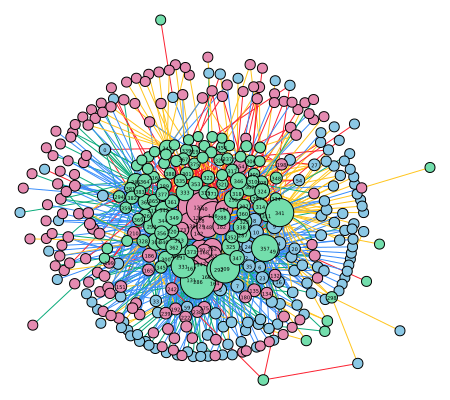

In [10]:
role_palette = {
    'host': "#73deac",
    'virus': "#e58bb1",
    'bacteria': "#8bc8e5",
}

g = ig.read("output/network.virusbact-host.multigraph.graphml", format='graphml')
edge_colors = [habitat_palette[edge['habitat']] for edge in g.es]
node_colors = [role_palette[vertex['role']] for vertex in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
normalized_sizes = [10 + 30 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]
degree_threshold = 10

degree_threshold = 5
labels = [
    dict(num_label=str(i), label=str(v['scientific_name'])) if degree > degree_threshold else dict(num_label="", label=str("")) for i, (v, degree) in enumerate(zip(g.vs, degrees))
]
labels = pd.DataFrame.from_records(labels)

random.seed(124)
layout = g.layout("kk")
ig.plot(g, layout=layout, edge_color=edge_colors, vertex_color=node_colors, vertex_size=normalized_sizes, target="figures/virusbact-host.multigraph.kk-layout.svg", vertex_label=labels['num_label'], vertex_label_size=5,
    bbox=(450, 400))

In [11]:
modules = pd.read_csv("scratch/modules.virusbact.weighted.csv", sep='\t').query('type == "row"')
# modules['value'] = modules['value'].apply(lambda x: x[1:])
modules

,index,type,value
0,1,row,Klasea pinnatifida
2,2,row,Aphyllanthes monspeliensis
3,2,row,Hieracium pilosella
8,3,row,Borago officinalis
9,3,row,Lavandula latifolia
...,...,...,...
333,16,row,Jasminum fruticans
334,16,row,Rubia peregrina
357,17,row,Anacyclus clavatus
358,17,row,Convolvulus arvensis


In [12]:
modules

,index,type,value
0,1,row,Klasea pinnatifida
2,2,row,Aphyllanthes monspeliensis
3,2,row,Hieracium pilosella
8,3,row,Borago officinalis
9,3,row,Lavandula latifolia
...,...,...,...
333,16,row,Jasminum fruticans
334,16,row,Rubia peregrina
357,17,row,Anacyclus clavatus
358,17,row,Convolvulus arvensis


In [13]:
host_habitat = organism_host[['host_taxon', 'habitat']].drop_duplicates()
host_habitat

,host_taxon,habitat
0,Cucumis melo,Crop
1,Convolvulus arvensis,Edge
2,Daucus sp,Edge
3,Cynodon dactylon,Edge
4,Quercus coccifera,Oak
...,...,...
955,Fumaria parviflora,Crop
985,Dittrichia viscosa,Wasteland
1022,Jasminum fruticans,Oak
1067,Crataegus monogyna,Oak


In [14]:
cont_table = pd.merge(
    modules, host_habitat, left_on='value', right_on='host_taxon'
).value_counts(
    ['index', 'habitat']
).reset_index().pivot(
    index='index', columns='habitat', values='count'
).fillna(0).astype(int)
cont_table

habitat,Crop,Edge,Oak,Wasteland
index,,,,
1,1,0,0,0
2,0,0,1,1
3,0,0,2,2
4,1,2,1,1
5,0,0,1,1
6,0,0,2,3
7,6,8,1,7
8,6,18,1,2
9,1,2,1,1


In [15]:
contingency_test = stats.chi2_contingency(cont_table)
print(f"p-value = {contingency_test.pvalue:8.6e}")
print(f"stat    = {contingency_test.statistic:8.6e}")
print(f"dof     = {contingency_test.dof:8d}")

p-value = 4.496822e-06
stat    = 1.045022e+02
dof     =       48


In [16]:
contingency_test.pvalue

4.496821667920341e-06

In [17]:
modules.value_counts(['index'])

index
15       35
8        18
7        12
13        9
10        8
16        4
11        4
9         3
17        3
6         3
4         3
3         3
2         2
12        2
5         1
14        1
1         1
Name: count, dtype: int64

In [18]:

modules = pd.read_csv("scratch/modules.virusbact.weighted.csv", sep='\t')#.pivot(index='index', columns='type', values='value')
module_palette = sns.color_palette('rainbow', n_colors=17)
modules['color'] = modules['index'].apply(lambda x: module_palette[x - 1])
modules = modules.set_index('value')
modules

,index,type,color
value,,,
Klasea pinnatifida,1,row,"(0.39019607843137255, 0.1716256791663596, 0.99..."
Sphingomonas sp. Leaf28,1,col,"(0.39019607843137255, 0.1716256791663596, 0.99..."
Aphyllanthes monspeliensis,2,row,"(0.2803921568627451, 0.33815827481581706, 0.98..."
Hieracium pilosella,2,row,"(0.2803921568627451, 0.33815827481581706, 0.98..."
Herbaspirillum seropedicae,2,col,"(0.2803921568627451, 0.33815827481581706, 0.98..."
...,...,...,...
Stenotrophomonas maltophilia,17,col,"(1.0, 0.1716256791663597, 0.08613293949614603)"
Streptomyces griseorubiginosus,17,col,"(1.0, 0.1716256791663597, 0.08613293949614603)"
ToLCNDV,17,col,"(1.0, 0.1716256791663597, 0.08613293949614603)"


In [19]:
g = ig.read("output/network.virusbact-host.multigraph.graphml", format='graphml')
edge_colors = [habitat_palette[edge['habitat']] for edge in g.es]
node_colors = [modules.loc[vertex['id']].color for vertex in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
normalized_sizes = [10 + 30 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]
degree_threshold = 10

degree_threshold = 5
labels = [
    dict(num_label=str(i), label=str(v['scientific_name'])) if degree > degree_threshold else dict(num_label="", label=str("")) for i, (v, degree) in enumerate(zip(g.vs, degrees))
]
labels = pd.DataFrame.from_records(labels)

random.seed(124)
layout = g.layout("kk")
ig.plot(
    g, layout=layout, edge_color=edge_colors, 
    vertex_color=node_colors, vertex_size=normalized_sizes, 
    target="figures/virusbact-host.multigraph.kk-layout.colbymodule.svg", 
    vertex_label=labels['num_label'], vertex_label_size=5,
    bbox=(300, 300)
)

KeyError: 'Lithodora fruticosa'

In [20]:
host_taxon = organism_host[['host_taxon']].drop_duplicates().rename(columns={'host_taxon':'scientific_name'})
host_taxon['type'] = 'host'
taxa_types = pd.concat([organism_host[['scientific_name', 'type']].drop_duplicates(), host_taxon])
taxa_types

,scientific_name,type
0,Bradyrhizobium elkanii,bacteria
1,Rhodococcoides fascians,bacteria
3,Frigoribacterium sp. Leaf164,bacteria
4,Bradyrhizobium sp. DFCI-1,bacteria
5,Chryseobacterium sp. Leaf201,bacteria
...,...,...
905,Bassia scoparia,host
908,Borago officinalis,host
985,Dittrichia viscosa,host
1022,Jasminum fruticans,host


In [21]:
modules.reset_index()

,value,index,type,color
0,Klasea pinnatifida,1,row,"(0.39019607843137255, 0.1716256791663596, 0.99..."
1,Sphingomonas sp. Leaf28,1,col,"(0.39019607843137255, 0.1716256791663596, 0.99..."
2,Aphyllanthes monspeliensis,2,row,"(0.2803921568627451, 0.33815827481581706, 0.98..."
3,Hieracium pilosella,2,row,"(0.2803921568627451, 0.33815827481581706, 0.98..."
4,Herbaspirillum seropedicae,2,col,"(0.2803921568627451, 0.33815827481581706, 0.98..."
...,...,...,...,...
392,Stenotrophomonas maltophilia,17,col,"(1.0, 0.1716256791663597, 0.08613293949614603)"
393,Streptomyces griseorubiginosus,17,col,"(1.0, 0.1716256791663597, 0.08613293949614603)"
394,ToLCNDV,17,col,"(1.0, 0.1716256791663597, 0.08613293949614603)"
395,Xaviernesmea rhizosphaerae,17,col,"(1.0, 0.1716256791663597, 0.08613293949614603)"


In [22]:
modules = pd.merge(modules.reset_index()[['index', 'value']], taxa_types, left_on='value', right_on='scientific_name')

In [23]:
modules_pvt = modules.value_counts(['index', 'type']).reset_index().pivot(index='index', columns='type', values='count').fillna(0)
modules_pvt['total'] = modules_pvt['bacteria'] + modules_pvt['host'] + modules_pvt['virus']
modules_pvt = modules_pvt.reset_index()

modules_melt = modules_pvt.melt(id_vars='index', value_vars=['bacteria', 'host', 'virus', ])
modules_melt

,index,type,value
0,1,bacteria,1.0
1,2,bacteria,4.0
2,3,bacteria,2.0
3,4,bacteria,29.0
4,5,bacteria,3.0
5,6,bacteria,2.0
6,7,bacteria,15.0
7,8,bacteria,11.0
8,9,bacteria,1.0
9,10,bacteria,7.0
